In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
import os
import sys
import glob
from sklearn.utils import shuffle
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.utils.multiclass import unique_labels

# import ML Classifiers 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [2]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

#File path to the zipped datafile
zip_path = '../../Data/Processed/Data_Compressed.zip'

#List of filenames to read from the zip file
filenames = [
    'Data_Compressed/all_normalized_features.csv',
    'Data_Compressed/kdd_all_normalized_features.csv',
    'Data_Compressed/kdd_expanded_all_scaled.csv',
    'Data_Compressed/kdd_merged_normalized_all.csv'
]

#Corresponding names for the DataFrames
df_names = [
    'xuetangx_df',
    'kdd_df',
    'kdd_expanded_df',
    'kdd_merged_df'
]

#Create an empty dictionary to store the DataFrames
dataframes = {}

#Open the zip file
z = zipfile.ZipFile(zip_path, 'r')

#Loop through the filenames and read them into DataFrames
for i, file in enumerate(filenames):
    print(f"Reading file: {file} from {zip_path}")
    
    #Read each CSV file directly from the zip
    f = z.open(file)
    dataframes[df_names[i]] = pd.read_csv(f)
    f.close()
    
    print(f"{df_names[i]} loaded with shape: {dataframes[df_names[i]].shape}\n")

#Close the zip file after reading
z.close()

#Assign individual DataFrames to variables
xuetangx_df = dataframes['xuetangx_df']
kdd_df = dataframes['kdd_df']
kdd_expanded_df = dataframes['kdd_expanded_df']
kdd_merged_df = dataframes['kdd_merged_df']

Reading file: Data_Compressed/all_normalized_features.csv from ../../Data/Processed/Data_Compressed.zip
xuetangx_df loaded with shape: (225642, 30)

Reading file: Data_Compressed/kdd_all_normalized_features.csv from ../../Data/Processed/Data_Compressed.zip
kdd_df loaded with shape: (200904, 17)

Reading file: Data_Compressed/kdd_expanded_all_scaled.csv from ../../Data/Processed/Data_Compressed.zip
kdd_expanded_df loaded with shape: (120542, 142)

Reading file: Data_Compressed/kdd_merged_normalized_all.csv from ../../Data/Processed/Data_Compressed.zip
kdd_merged_df loaded with shape: (120542, 158)



In [3]:
#Isolate the X and y features for the kdd dataset
kdd_X = kdd_df.drop(columns=['truth'])
kdd_X = kdd_X.drop(columns=['enrollment_id'])
kdd_y = kdd_df['truth']

In [4]:
#Split the kdd dataset into training and testing sets
kdd_X_train, kdd_X_test, kdd_y_train, kdd_y_test = train_test_split(kdd_X, kdd_y, test_size=0.2, random_state=100)

In [5]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score

# Create a dataframe to store results
results_df = pd.DataFrame(columns=['Model', 'Test Accuracy', 'CV Accuracy', 'CV Std Dev'])

# Create a dataframe to store results
results_df = pd.DataFrame(columns=['Model', 'Test Accuracy', 'CV Accuracy', 'CV Std Dev'])

def evaluate_model(model, model_name, kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, scoring='roc_auc', random_seed=100):
    kfold = KFold(n_splits=5, random_state=random_seed, shuffle=True)
    cv_results = cross_val_score(model, kdd_X_train, kdd_y_train, cv=kfold, scoring=scoring)
    
    model.fit(kdd_X_train, kdd_y_train)
    y_pred = model.predict(kdd_X_test)
    
    cm = confusion_matrix(kdd_y_test, y_pred)
    acc = accuracy_score(kdd_y_test, y_pred)
    
    global results_df
    new_row = pd.DataFrame({'Model': [model_name], 'Test Accuracy': [acc], 'CV Accuracy': [cv_results.mean()], 'CV Std Dev': [cv_results.std()]})
    results_df = pd.concat([results_df, new_row], ignore_index=True)
    
    print(f'\nModel: {model_name}')
    print(f'Cross-validation mean score ({scoring}): {cv_results.mean():.4f} ({cv_results.std():.4f})')
    print(f'Accuracy: {acc:.4f}')
    print('Confusion Matrix:')
    print(cm)
    print('-' * 50)

# Define models
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', multi_class='auto'),
    'LDA': LinearDiscriminantAnalysis(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100),
    'Random Forest': RandomForestClassifier(n_estimators=10),
    'XGBoost': XGBClassifier()
}

def run_experiments(kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test):
    for name, model in models.items():
        evaluate_model(model, name, kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test)

# Run experiments for the first 8 models
run_experiments(kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test)

# Display results
display(results_df)

/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/


Model: Logistic Regression
Cross-validation mean score (roc_auc): 0.8451 (0.0047)
Accuracy: 0.8534
Confusion Matrix:
[[ 3544  4794]
 [ 1096 30747]]
--------------------------------------------------

Model: LDA
Cross-validation mean score (roc_auc): 0.8430 (0.0048)
Accuracy: 0.8490
Confusion Matrix:
[[ 3157  5181]
 [  887 30956]]
--------------------------------------------------

Model: KNN
Cross-validation mean score (roc_auc): 0.7768 (0.0083)
Accuracy: 0.8449
Confusion Matrix:
[[ 4101  4237]
 [ 1996 29847]]
--------------------------------------------------

Model: Decision Tree
Cross-validation mean score (roc_auc): 0.6168 (0.0025)
Accuracy: 0.8057
Confusion Matrix:
[[ 4034  4304]
 [ 3505 28338]]
--------------------------------------------------

Model: Naive Bayes
Cross-validation mean score (roc_auc): 0.8192 (0.0041)
Accuracy: 0.8473
Confusion Matrix:
[[ 3779  4559]
 [ 1578 30265]]
--------------------------------------------------


/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/kirstintretter/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the S


Model: AdaBoost
Cross-validation mean score (roc_auc): 0.8475 (0.0043)
Accuracy: 0.8595
Confusion Matrix:
[[ 4213  4125]
 [ 1522 30321]]
--------------------------------------------------

Model: Random Forest
Cross-validation mean score (roc_auc): 0.8123 (0.0032)
Accuracy: 0.8441
Confusion Matrix:
[[ 4495  3843]
 [ 2421 29422]]
--------------------------------------------------

Model: XGBoost
Cross-validation mean score (roc_auc): 0.8470 (0.0043)
Accuracy: 0.8600
Confusion Matrix:
[[ 4121  4217]
 [ 1410 30433]]
--------------------------------------------------


,Model,Test Accuracy,CV Accuracy,CV Std Dev
0,Logistic Regression,0.853413,0.845087,0.004741
1,LDA,0.848983,0.842981,0.004840
2,KNN,0.844877,0.776795,0.008252
3,Decision Tree,0.805654,0.616756,0.002522
4,Naive Bayes,0.847266,0.819150,0.004061
5,AdaBoost,0.859461,0.847548,0.004302
6,Random Forest,0.844105,0.812332,0.003153
7,XGBoost,0.859959,0.846952,0.004260


In [6]:
# This code block did not run on my computer - I gave it about an hour and then stopped it. Chance ran the SVM models overnight on his machine so I will be using the output from that.

# # Sample 20% of the dataset
# kdd_sampled = kdd_df.sample(frac=0.2, random_state=100)
# kdd_X = kdd_df.drop(columns=['truth'])
# kdd_X = kdd_X.drop(columns=['enrollment_id'])
# kdd_y = kdd_df['truth']

# # Split the sampled data
# kdd_X_train, kdd_X_test, kdd_y_train, kdd_y_test = train_test_split(kdd_X, kdd_y, test_size=0.2, random_state=100)

# # Create a dataframe to store results
# results_df = pd.DataFrame(columns=['Model', 'Test Accuracy', 'CV Accuracy', 'CV Std Dev'])

# def evaluate_model(model, model_name, kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, scoring='roc_auc', random_seed=100):
#     kfold = KFold(n_splits=5, random_state=random_seed, shuffle=True)
#     cv_results = cross_val_score(model, kdd_X_train, kdd_y_train, cv=kfold, scoring=scoring)
    
#     model.fit(kdd_X_train, kdd_y_train)
#     y_pred = model.predict(kdd_X_test)
    
#     cm = confusion_matrix(kdd_y_test, y_pred)
#     acc = accuracy_score(kdd_y_test, y_pred)
    
#     global results_df
#     new_row = pd.DataFrame({'Model': [model_name], 'Test Accuracy': [acc], 'CV Accuracy': [cv_results.mean()], 'CV Std Dev': [cv_results.std()]})
#     results_df = pd.concat([results_df, new_row], ignore_index=True)
    
#     print(f'\nModel: {model_name}')
#     print(f'Cross-validation mean score ({scoring}): {cv_results.mean():.4f} ({cv_results.std():.4f})')
#     print(f'Accuracy: {acc:.4f}')
#     print('Confusion Matrix:')
#     print(cm)
#     print('-' * 50)

# # Run SVM model only
# evaluate_model(SVC(gamma='auto'), 'SVM', kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test)

# # Display results
# display(results_df)

In [7]:
folder_path = '../../Analysis/SVM_Results'
SVM_results = pd.read_csv(os.path.join(folder_path, 'kdd_svm_results.csv'))

In [8]:
SVM_results = pd.DataFrame(SVM_results)

In [9]:
SVM_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1 non-null      int64  
 1   Classifiers    1 non-null      object 
 2   Mean Accuracy  1 non-null      float64
 3   SD             1 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 164.0+ bytes


In [10]:
SVM_results = SVM_results.drop(columns = ['Unnamed: 0'])

In [11]:
SVM_results = SVM_results.rename(columns={'Classifiers':'Model', 'Mean Accuracy':'CV Accuracy', 'SD':'CV Std Dev'})
SVM_results

,Model,CV Accuracy,CV Std Dev
0,SVM,0.85903,0.00144


In [13]:
SVM_results["Test Accuracy"] = None  # or set it to a placeholder value like 0.0
SVM_results = SVM_results[results_df.columns]  # Reorder columns to match

# Now concatenate
results_df = pd.concat([results_df, SVM_results], ignore_index=True)

/var/folders/mj/_5nwhhkd5cjbp6mcqnk7hh540000gn/T/ipykernel_83360/3481556001.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, SVM_results], ignore_index=True)


In [14]:
results_df

,Model,Test Accuracy,CV Accuracy,CV Std Dev
0,Logistic Regression,0.853413,0.845087,0.004741
1,LDA,0.848983,0.842981,0.004840
2,KNN,0.844877,0.776795,0.008252
3,Decision Tree,0.805654,0.616756,0.002522
4,Naive Bayes,0.847266,0.819150,0.004061
5,AdaBoost,0.859461,0.847548,0.004302
6,Random Forest,0.844105,0.812332,0.003153
7,XGBoost,0.859959,0.846952,0.004260
8,SVM,NaN,0.859030,0.001440


In [15]:
desired_order = [
    "Random Forest", "XGBoost", "AdaBoost", "Decision Tree", 
    "KNN", "SVM", "Logistic Regression", "LDA", "Naive Bayes"
]

results_df["Model"] = pd.Categorical(results_df["Model"], categories=desired_order, ordered=True)
results_df = results_df.sort_values("Model").reset_index(drop=True)

# Display the reordered results
display(results_df)

,Model,Test Accuracy,CV Accuracy,CV Std Dev
0,Random Forest,0.844105,0.812332,0.003153
1,XGBoost,0.859959,0.846952,0.004260
2,AdaBoost,0.859461,0.847548,0.004302
3,Decision Tree,0.805654,0.616756,0.002522
4,KNN,0.844877,0.776795,0.008252
5,SVM,NaN,0.859030,0.001440
6,Logistic Regression,0.853413,0.845087,0.004741
7,LDA,0.848983,0.842981,0.004840
8,Naive Bayes,0.847266,0.819150,0.004061


### Comparing results against the original

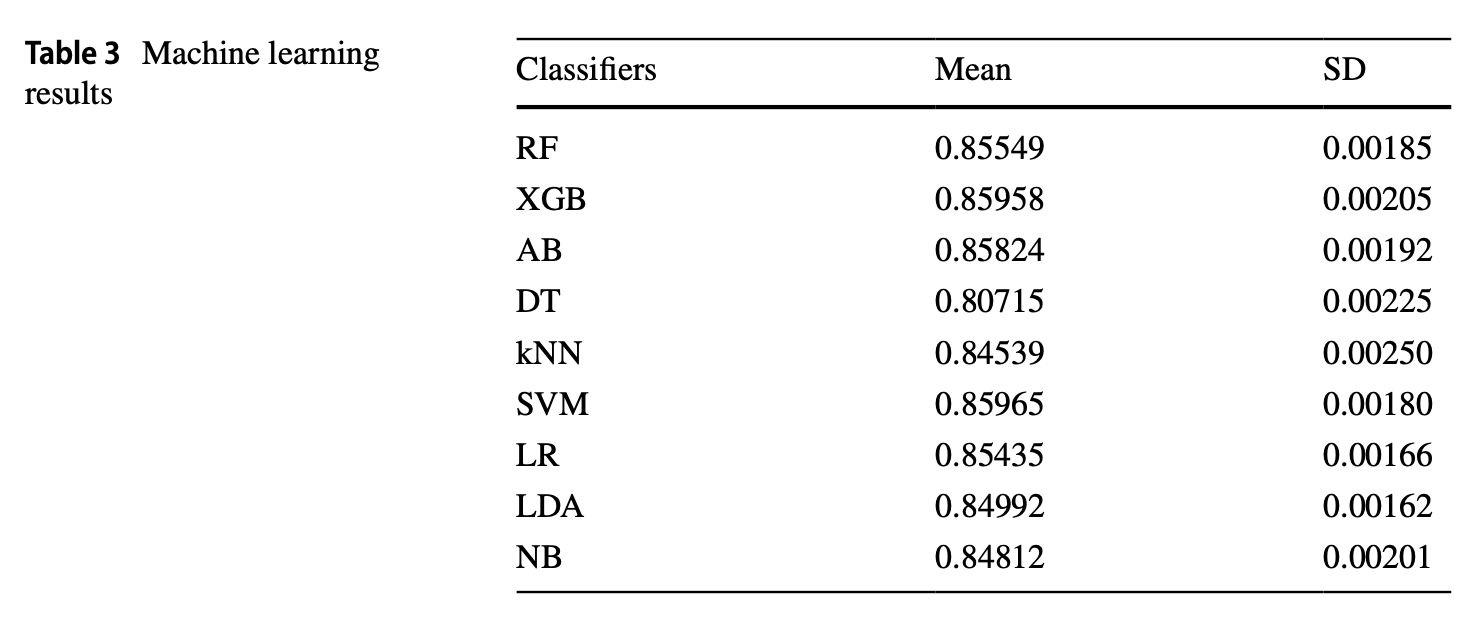